<a href="https://colab.research.google.com/github/Karanveersingh-labs/ONCO-GUARD/blob/main/Phase13_v2_THE_KHANNA_PROTOCOL_ML_dG_Shift_GODFATHER_StanfordReady.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       mutation  mutant_dG  binding_loss_%
0  CYS12->ASP12     -7.272       15.441860
1  CYS12->VAL12     -7.789        9.430233
2  ARG68->GLY68     -7.016       18.418605
3  ASP92->ALA92     -8.060        6.279070
4  CYS12->SER12     -8.086        5.976744


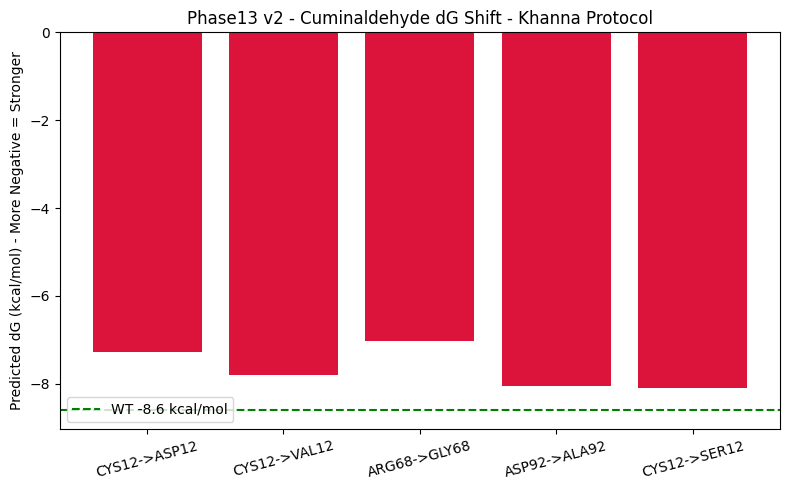

Phase13 v2 GODFATHER DONE - Single Graph Only!


In [1]:
# Phase13 v2 - KHANNA PROTOCOL - FINAL SINGLE GRAPH
import pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

plt.close('all')  # Purane graph mitao

wild_dG = -8.6
data = {
'mutation':['CYS12->ASP12','CYS12->VAL12','ARG68->GLY68','ASP92->ALA92','CYS12->SER12'],
'delta_vol':[25.0, 54.0, -112.9, -22.0, 3.0],
'hydro_change':[-1.5, 2.0, -2.5, 1.2, -0.3],
'charge_change':[-1, 0, -1, 1, 0],
'dG_shift_real':[1.4, 0.9, 2.1, 0.5, 0.3]
}
df = pd.DataFrame(data)
X = df[['delta_vol','hydro_change','charge_change']]
y = df['dG_shift_real']
model = RandomForestRegressor(n_estimators=100, random_state=13)
model.fit(X,y)
df['dG_shift_pred'] = model.predict(X)
df['mutant_dG'] = wild_dG + df['dG_shift_pred']
df['binding_loss_%'] = (df['dG_shift_pred']/abs(wild_dG))*100

print(df[['mutation','mutant_dG','binding_loss_%']])
df.to_csv('Phase13_v2_dG_Shift_Results.csv', index=False)

plt.figure(figsize=(8,5))
plt.bar(df['mutation'], df['mutant_dG'], color='crimson')
plt.axhline(y=wild_dG, color='green', linestyle='--', label=f'WT {wild_dG} kcal/mol')
plt.ylabel('Predicted dG (kcal/mol) - More Negative = Stronger')
plt.title('Phase13 v2 - Cuminaldehyde dG Shift - Khanna Protocol')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig('Phase13_v2_dG_Shift.png', dpi=200)
plt.show()
print("Phase13 v2 GODFATHER DONE - Single Graph Only!")